Step 0: Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
#NLP
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download('stopwords')

# get the path always from project root folder
notebook_path = Path(os.getcwd())
for parent in notebook_path.parents:
    if(parent/".git").exists():
        project_root = parent
        break

data_path = project_root / "data" / "raw" / "customer_support_tickets.csv"
df = pd.read_csv(data_path)



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\30313\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Step 1: Basic Data Understanding

1.1 structure overview

In [14]:
df.shape

(8469, 17)

In [15]:
df.columns


Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

In [16]:
df.head()


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   str    
 2   Customer Email                8469 non-null   str    
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   str    
 5   Product Purchased             8469 non-null   str    
 6   Date of Purchase              8469 non-null   str    
 7   Ticket Type                   8469 non-null   str    
 8   Ticket Subject                8469 non-null   str    
 9   Ticket Description            8469 non-null   str    
 10  Ticket Status                 8469 non-null   str    
 11  Resolution                    2769 non-null   str    
 12  Ticket Priority               8469 non-null   str    
 13  Ticket Channel

1.2 Missing values

In [8]:
df.isnull().sum().sort_values(ascending=False)

Customer Satisfaction Rating    5700
Resolution                      5700
Time to Resolution              5700
First Response Time             2819
Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Ticket Subject                     0
Ticket Type                        0
Date of Purchase                   0
Product Purchased                  0
Ticket Priority                    0
Ticket Status                      0
Ticket Description                 0
Ticket Channel                     0
dtype: int64

no missing ticket text



1.3 Duplicate tickets

In [10]:
df.duplicated().sum()

np.int64(0)

In [ ]:
no duplicated complaints

Step 2: Create a clean working dataframe

In [18]:
# keep original safe
eda_df = df.copy()

# drop columns you should not use for NLP
drop_cols = ["Ticket ID", "Customer Name", "Customer Email"]
eda_df = eda_df.drop(columns=drop_cols)

# rename for convenience
eda_df = eda_df.rename(columns={
    "Ticket Description": "text",
    "Ticket Subject": "subject",
    "Ticket Type": "type",
    "Product Purchased": "product",
    "Ticket Priority": "priority",
    "Ticket Status": "status",
    "Ticket Channel": "channel",
    "Customer Age": "age",
    "Customer Gender": "gender",
    "Date of Purchase": "purchase_date",
    "First Response Time": "first_response_time",
    "Time to Resolution": "resolution_time",
    "Customer Satisfaction Rating": "satisfaction"
})

eda_df.head()


,age,gender,product,purchase_date,type,subject,text,status,Resolution,priority,channel,first_response_time,resolution_time,satisfaction
0,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


Step 3: Do a data-quality audit

3.1 Missingness by status

In [19]:
for col in ["resolution_time", "first_response_time", "satisfaction", "Resolution"]:
    if col in eda_df.columns:
        print("\n", col)
        print(pd.crosstab(eda_df["status"], eda_df[col].isna(), margins=True))


 resolution_time
resolution_time            False  True   All
status                                      
Closed                      2769     0  2769
Open                           0  2819  2819
Pending Customer Response      0  2881  2881
All                         2769  5700  8469

 first_response_time
first_response_time        False  True   All
status                                      
Closed                      2769     0  2769
Open                           0  2819  2819
Pending Customer Response   2881     0  2881
All                         5650  2819  8469

 satisfaction
satisfaction               False  True   All
status                                      
Closed                      2769     0  2769
Open                           0  2819  2819
Pending Customer Response      0  2881  2881
All                         2769  5700  8469

 Resolution
Resolution                 False  True   All
status                                      
Closed                      2769

- resoluution_time,resolution, and stasfaction only exist for Closed tickets
- first_response_time exists for Closed and Pending Customer Response
- open tickets have no first_reponse_time

So these missing values reflect the support workflow 

3.2 Duplicate descriptions

In [20]:
eda_df["text"].duplicated().sum()

np.int64(392)

3.3 Placeholder / template artifacts

In [21]:
eda_df["text"].astype(str).str.contains(r"\{product_purchased\}", regex=True).sum()

np.int64(8469)

The missingness pattern is structural and strongly associated with ticket status, indicating that workflow-related fields such as resolution, satisfaction, and response timestamps should not be imputed or treated as universally available features. In addition, all ticket descriptions contain the placeholder {product_purchased}, showing that the corpus is templated rather than fully naturalistic. Therefore, preprocessing must first substitute the placeholder with the actual product name before performing duplicate analysis or text-based modelling.

Step 4: Repair the text first, then re-check duplicates

In [34]:
import pandas as pd

eda_df = df.copy()

eda_df = eda_df.rename(columns={
    "Ticket Description": "text",
    "Ticket Subject": "subject",
    "Ticket Type": "type",
    "Product Purchased": "product",
    "Ticket Priority": "priority",
    "Ticket Status": "status",
    "Ticket Channel": "channel",
    "Customer Age": "age",
    "Customer Gender": "gender",
    "Date of Purchase": "purchase_date",
    "First Response Time": "first_response_time",
    "Time to Resolution": "resolution_time",
    "Customer Satisfaction Rating": "satisfaction"
})

# keep the raw version
eda_df["text_raw"] = eda_df["text"].astype(str)

# replace placeholder with actual product name
eda_df["text_filled"] = eda_df.apply(
    lambda row: row["text_raw"].replace("{product_purchased}", str(row["product"])),
    axis=1
)

# compare duplicate counts before and after replacement
dup_before = eda_df["text_raw"].duplicated().sum()
dup_after = eda_df["text_filled"].duplicated().sum()

print("Duplicate descriptions BEFORE replacement:", dup_before)
print("Duplicate descriptions AFTER replacement:", dup_after)

# show a few examples
for i in range(5):
    print("\n" + "="*80)
    print(f"Row {i}")
    print("SUBJECT:", eda_df.loc[i, "subject"])
    print("PRODUCT:", eda_df.loc[i, "product"])
    print("\nRAW TEXT:")
    print(eda_df.loc[i, "text_raw"])
    print("\nFILLED TEXT:")
    print(eda_df.loc[i, "text_filled"])

Duplicate descriptions BEFORE replacement: 392
Duplicate descriptions AFTER replacement: 71

Row 0
SUBJECT: Product setup
PRODUCT: GoPro Hero

RAW TEXT:
I'm having an issue with the {product_purchased}. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

FILLED TEXT:
I'm having an issue with the GoPro Hero. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

Row 1
SUBJECT: Peripheral compatibility
PRODUCT: LG Smart TV

RAW TEXT:
I'm having an issue with the {product_purchased}. Please assist.

If you need to change an existing product.

I'm having an issue with the {product_purchased}. Please assist.

If The issue I'm facing

Replacing {product_purchased} with the true product name was a necessary preprocessing step. Before replacement, the corpus appeared to contain 392 duplicate descriptions, but this fell to 71 after substitution, indicating that most apparent duplication was an artifact of templated text rather than genuine repetition. The sample descriptions also reveal that the dataset contains substantial boilerplate and noisy inserted fragments, suggesting that careful text cleaning will be essential before clustering or topic discovery.

Step 5: Build an analysis-ready text column and inspect text length / outliers

just do minimal but sensible cleaning, not aggressive cleaning yet.

this step is for:
1. create a usable text column for NLP
2. measure lenght distribution
3. inpsect the shortest and longest tickets
4. see how much weird noise still remains


Character length summary:
count    8469.000000
mean      270.209706
std        45.659363
min       131.000000
25%       249.000000
50%       280.000000
75%       301.000000
max       376.000000
Name: char_len, dtype: float64

Word count summary:
count    8469.000000
mean       51.099421
std         8.775720
min        23.000000
25%        47.000000
50%        53.000000
75%        57.000000
max        70.000000
Name: word_count, dtype: float64


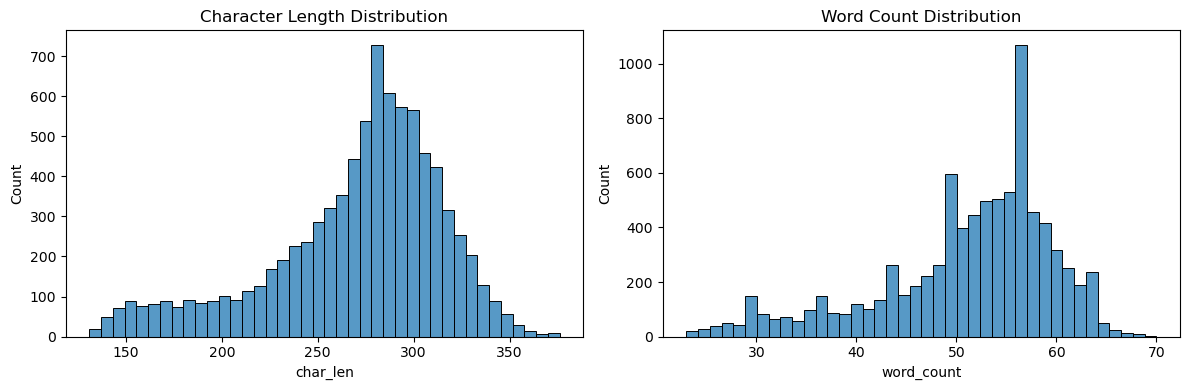


===== 5 shortest cleaned texts =====
                   subject  ... word_count
2249        Refund request  ...         23
5726      Delivery problem  ...         23
1656         Payment issue  ...         24
2919  Installation support  ...         24
6642       Network problem  ...         24

[5 rows x 5 columns]

===== 5 longest cleaned texts =====
                   subject  ... word_count
2892       Network problem  ...         70
5897        Refund request  ...         69
7962       Network problem  ...         68
636   Cancellation request  ...         68
7689        Hardware issue  ...         68

[5 rows x 5 columns]


In [35]:

# start from the filled text already created
def basic_clean(text):
    text = str(text).lower()
    
    # remove URLs and emails
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # remove standalone numeric codes like zip codes / version-like fragments
    text = re.sub(r'\b\d+(?:\.\d+)+\b', ' ', text)   # e.g. 1.8.3
    text = re.sub(r'\b\d{4,}\b', ' ', text)          # e.g. 71701
    
    # normalize punctuation to spaces
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

eda_df["text_clean_basic"] = eda_df["text_filled"].apply(basic_clean)

# length features
eda_df["char_len"] = eda_df["text_clean_basic"].str.len()
eda_df["word_count"] = eda_df["text_clean_basic"].str.split().apply(len)

# summary statistics
print("Character length summary:")
print(eda_df["char_len"].describe())

print("\nWord count summary:")
print(eda_df["word_count"].describe())

# histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(eda_df["char_len"], bins=40, ax=axes[0])
axes[0].set_title("Character Length Distribution")

sns.histplot(eda_df["word_count"], bins=40, ax=axes[1])
axes[1].set_title("Word Count Distribution")

plt.tight_layout()
plt.show()

# inspect very short and very long cases
print("\n===== 5 shortest cleaned texts =====")
print(eda_df.sort_values("word_count")[["subject", "product", "text_filled", "text_clean_basic", "word_count"]].head(5))

print("\n===== 5 longest cleaned texts =====")
print(eda_df.sort_values("word_count", ascending=False)[["subject", "product", "text_filled", "text_clean_basic", "word_count"]].head(5))

After placeholder substitution and basic cleaning, ticket descriptions were found to be relatively uniform in length, with a median of 53 words and an interquartile range of 47–57 words. The narrow spread and visible spikes in the word-count distribution suggest that the corpus contains repeated structural templates rather than fully free-form customer narratives. This implies that document length is unlikely to be a major source of variation in downstream clustering, while lexical and phrasal patterns are likely to be more important.

Step 6: Frequent words and bigrams

need to find answers for:
1. what issue language appears most often?
2. how much of the corpus is real issue content vs boilerplate?
3. which phrases may become cluster anchors later?

Top 30 unigrams:
         term  count
0       issue  11532
1      having   6430
2      assist   6258
3          ve   6120
4     product   3106
5     problem   2285
6        data   1667
7    software   1555
8     account   1467
9       steps   1390
10      error   1321
11    noticed   1208
12       help   1181
13   persists   1178
14    resolve   1165
15     update   1157
16    message   1134
17     device   1118
18     unable   1088
19         lg   1046
20       sony   1044
21      tried   1034
22      using   1031
23       need   1018
24  microsoft   1000
25    started    981
26        use    978
27     action    974
28      times    972
29    support    940


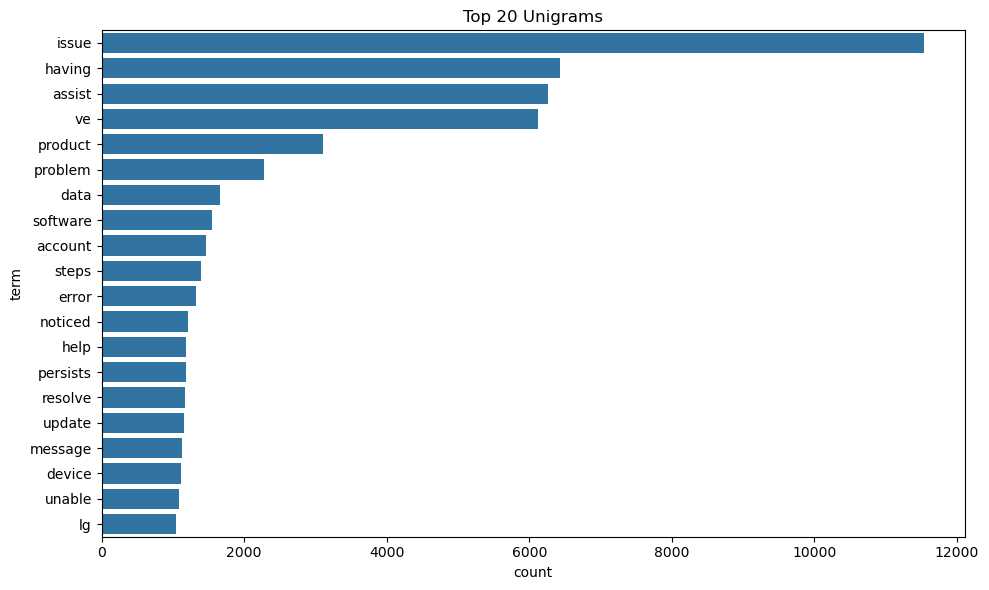


Top 30 bigrams:
                   bigram  count
15           having issue   6175
44             ve noticed   1191
20         issue persists   1176
9           error message    972
47               ve tried    968
43             ve checked    748
34        resolve problem    747
40  troubleshooting steps    684
46            ve recently    673
25        nintendo switch    610
3          assist product    552
37          soon possible    511
49             works fine    507
36       software updates    505
11          factory reset    504
30           problem didn    503
7               didn help    502
16         hoping resolve    502
45           ve performed    502
28      performed factory    502
0       acts unexpectedly    499
12             fine times    499
17     intermittent works    499
10    facing intermittent    499
18           issue facing    499
39             times acts    499
27        perform desired    490
26         option perform    490
41          unable option 

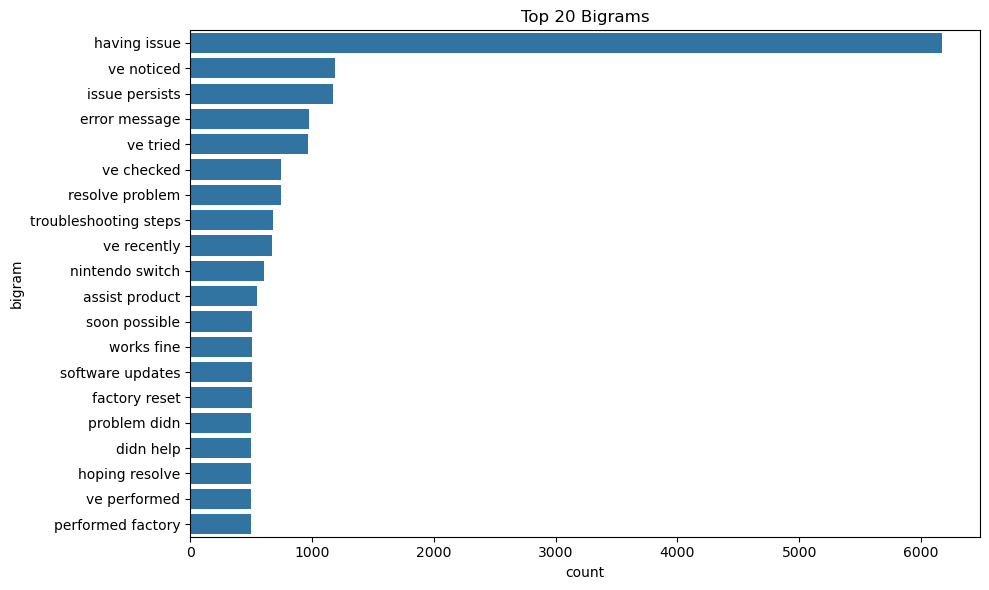

In [36]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from collections import Counter

# remove standard English stopwords for frequency analysis
stop_words = set(ENGLISH_STOP_WORDS)

def remove_stopwords(text):
    tokens = str(text).split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return " ".join(tokens)

eda_df["text_freq_ready"] = eda_df["text_clean_basic"].apply(remove_stopwords)

# ---- top unigrams ----
all_tokens = " ".join(eda_df["text_freq_ready"]).split()
unigram_counts = Counter(all_tokens)

top_unigrams = pd.DataFrame(
    unigram_counts.most_common(30),
    columns=["term", "count"]
)

print("Top 30 unigrams:")
print(top_unigrams)

plt.figure(figsize=(10,6))
sns.barplot(data=top_unigrams.head(20), x="count", y="term")
plt.title("Top 20 Unigrams")
plt.tight_layout()
plt.show()

# ---- top bigrams ----
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words="english",
    max_features=50,
    min_df=5
)

X_bi = bigram_vectorizer.fit_transform(eda_df["text_clean_basic"])

bigram_counts = pd.DataFrame({
    "bigram": bigram_vectorizer.get_feature_names_out(),
    "count": X_bi.toarray().sum(axis=0)
}).sort_values("count", ascending=False)

print("\nTop 30 bigrams:")
print(bigram_counts.head(30))

plt.figure(figsize=(10,6))
sns.barplot(data=bigram_counts.head(20), x="count", y="bigram")
plt.title("Top 20 Bigrams")
plt.tight_layout()
plt.show()

Frequency analysis on the basic-cleaned text showed that the corpus is still dominated by boilerplate support language such as “having issue”, “please assist”, and repeated first-person troubleshooting phrases. In addition, contraction fragments such as “ve” and “didn” appear as high-frequency tokens, indicating that further preprocessing is needed. Product names also appear prominently, suggesting that unsupervised methods may otherwise cluster tickets by product rather than by issue type. Therefore, a more issue-focused text representation should remove domain-generic boilerplate and product tokens while keeping product metadata separately for downstream interpretation.

Step 7: Build an issue-focused text column

create a cleaner version for issue mining by:

1. removing each row’s own product name from the text
2. removing boilerplate/domain-generic words
3. removing contraction artifacts
4. checking whether the top terms now become more meaningful

Empty issue-ready texts: 13
Issue-ready word count summary:
count    8469.00000
mean       12.98713
std         4.59947
min         0.00000
25%        10.00000
50%        13.00000
75%        16.00000
max        29.00000
Name: text_issue_ready, dtype: float64

===== 5 examples: before vs after =====

Row 0
SUBJECT: Product setup
PRODUCT: GoPro Hero

TEXT_FILLED:
I'm having an issue with the GoPro Hero. Please assist.

Your billing zip code is: 71701.

We appreciate that you have requested a website address.

Please double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.

TEXT_ISSUE_READY:
billing zip code website address email address

Row 1
SUBJECT: Peripheral compatibility
PRODUCT: LG Smart TV

TEXT_FILLED:
I'm having an issue with the LG Smart TV. Please assist.

If you need to change an existing product.

I'm having an issue with the LG Smart TV. Please assist.

If The issue I'm facing is intermittent. Sometimes it work

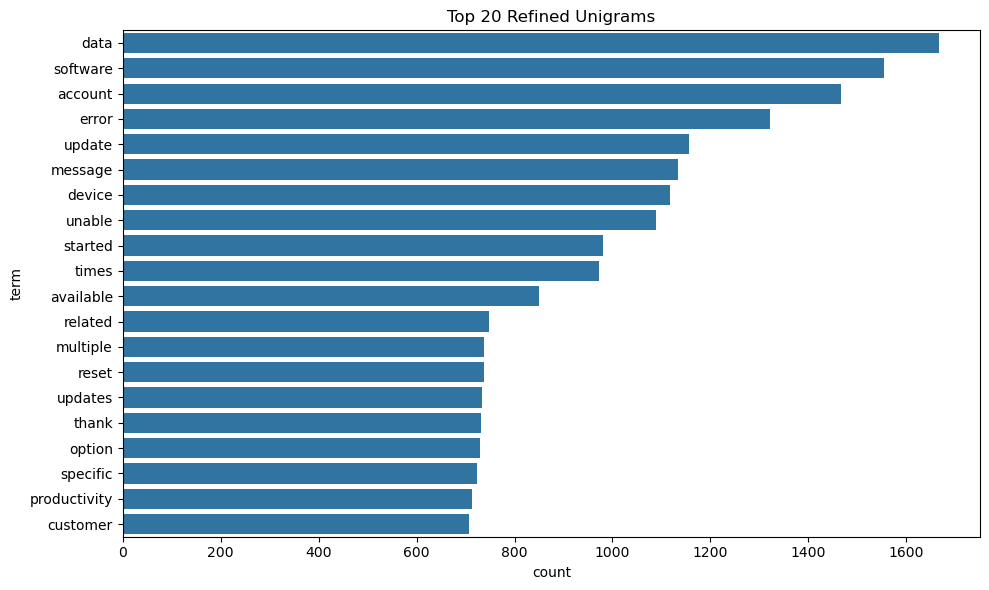


Top 30 refined bigrams:
                  bigram  count
15         error message    972
40      software updates    505
16         factory reset    504
34          reset hoping    502
2      acts unexpectedly    499
20    intermittent times    499
43            times acts    499
45         unable option    491
27        option perform    490
29       perform desired    490
47      updated firmware    486
17      firmware started    485
4      afterward related    485
3         affecting work    485
5   assistance affecting    485
49     work productivity    485
41     started happening    485
32        related update    485
18   happening afterward    485
13             does mean    479
1           action guide    478
12        desired action    478
36           screen says    473
28        peculiar error    472
24       message popping    472
23          message does    472
35            says error    472
30        popping screen    472
19         haven changes    471
39       softwa

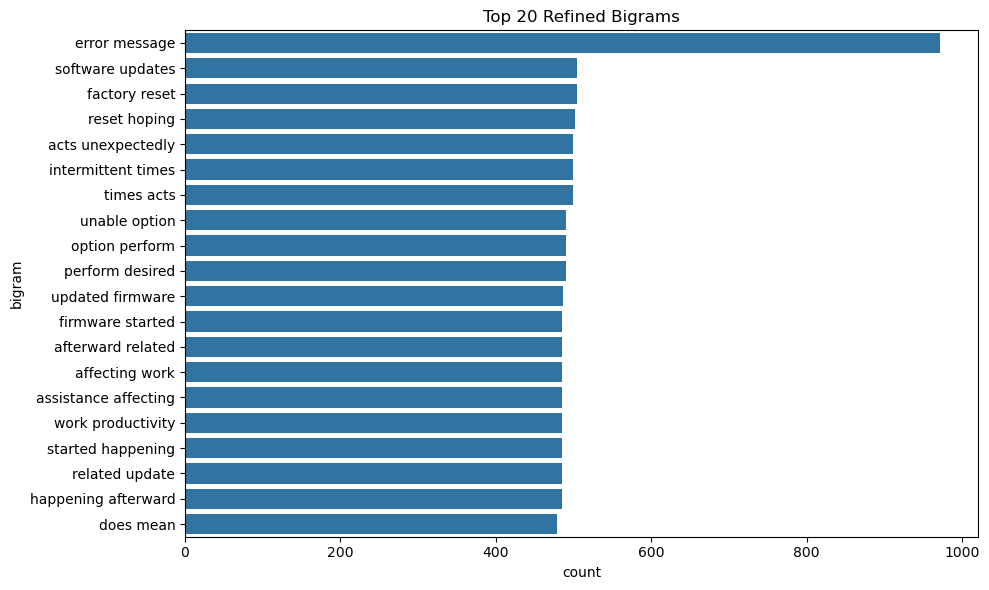

In [37]:
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. Remove each row's product tokens from its text
# ----------------------------
def remove_product_tokens(text, product):
    product_tokens = re.sub(r'[^a-z0-9\s]', ' ', str(product).lower()).split()
    tokens = str(text).split()
    tokens = [t for t in tokens if t not in product_tokens]
    return " ".join(tokens)

eda_df["text_no_product"] = eda_df.apply(
    lambda row: remove_product_tokens(row["text_clean_basic"], row["product"]),
    axis=1
)

# ----------------------------
# 2. Define custom domain stopwords
# ----------------------------
domain_stopwords = {
    "issue", "issues", "having", "assist", "please", "problem", "problems",
    "help", "support", "product", "products", "using", "use", "used",
    "need", "needed", "tried", "checked", "noticed", "persists", "persist",
    "resolve", "resolved", "steps", "troubleshooting", "recently",
    "performed", "works", "fine", "soon", "possible", "facing", "faced",
    "trying", "request", "requested", "appreciate", "double", "check",
    "manual", "mentioned", "user", "came", "please", "assist", "ive",
    "im", "really"
}

contraction_artifacts = {
    "ve", "ll", "re", "don", "didn", "doesn", "isn", "aren", "wasn",
    "weren", "won", "wouldn", "couldn", "shouldn"
}

stop_words_refined = set(ENGLISH_STOP_WORDS).union(domain_stopwords).union(contraction_artifacts)

# ----------------------------
# 3. Remove stopwords and short junk tokens
# ----------------------------
def make_issue_ready(text):
    tokens = str(text).split()
    tokens = [t for t in tokens if t not in stop_words_refined and len(t) > 2]
    return " ".join(tokens)

eda_df["text_issue_ready"] = eda_df["text_no_product"].apply(make_issue_ready)

# ----------------------------
# 4. Quick sanity checks
# ----------------------------
print("Empty issue-ready texts:", (eda_df["text_issue_ready"].str.strip() == "").sum())
print("Issue-ready word count summary:")
print(eda_df["text_issue_ready"].str.split().apply(len).describe())

print("\n===== 5 examples: before vs after =====")
sample_idx = [0, 1, 2, 3, 4]
for i in sample_idx:
    print("\n" + "="*80)
    print(f"Row {i}")
    print("SUBJECT:", eda_df.loc[i, "subject"])
    print("PRODUCT:", eda_df.loc[i, "product"])
    print("\nTEXT_FILLED:")
    print(eda_df.loc[i, "text_filled"])
    print("\nTEXT_ISSUE_READY:")
    print(eda_df.loc[i, "text_issue_ready"])

# ----------------------------
# 5. Refined unigram analysis
# ----------------------------
all_tokens_refined = " ".join(eda_df["text_issue_ready"]).split()
unigram_counts_refined = Counter(all_tokens_refined)

top_unigrams_refined = pd.DataFrame(
    unigram_counts_refined.most_common(30),
    columns=["term", "count"]
)

print("\nTop 30 refined unigrams:")
print(top_unigrams_refined)

plt.figure(figsize=(10,6))
sns.barplot(data=top_unigrams_refined.head(20), x="count", y="term")
plt.title("Top 20 Refined Unigrams")
plt.tight_layout()
plt.show()

# ----------------------------
# 6. Refined bigram analysis
# ----------------------------
bigram_vectorizer_refined = CountVectorizer(
    ngram_range=(2,2),
    max_features=50,
    min_df=5
)

X_bi_refined = bigram_vectorizer_refined.fit_transform(eda_df["text_issue_ready"])

bigram_counts_refined = pd.DataFrame({
    "bigram": bigram_vectorizer_refined.get_feature_names_out(),
    "count": X_bi_refined.toarray().sum(axis=0)
}).sort_values("count", ascending=False)

print("\nTop 30 refined bigrams:")
print(bigram_counts_refined.head(30))

plt.figure(figsize=(10,6))
sns.barplot(data=bigram_counts_refined.head(20), x="count", y="bigram")
plt.title("Top 20 Refined Bigrams")
plt.tight_layout()
plt.show()

After removing product tokens and domain-generic boilerplate, the most frequent terms became substantially more issue-focused, with prominent signals such as “error message”, “software updates”, and “factory reset”. This indicates that the refined representation is better suited to identifying recurring issue themes. However, sample rows show that aggressive filtering can also remove useful context and leave behind noisy fragments, so the refined text should be treated as one representation among several rather than a universally superior preprocessing choice.

Step 8: Structured distribution and relationship audit

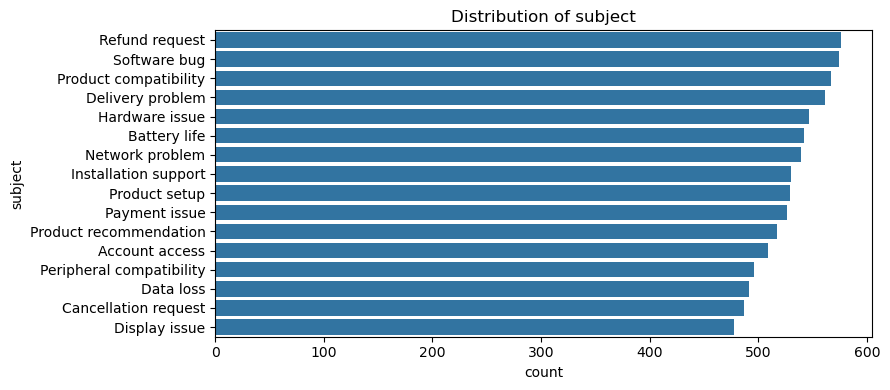


Value counts for subject:
subject
Refund request              576
Software bug                574
Product compatibility       567
Delivery problem            561
Hardware issue              547
Battery life                542
Network problem             539
Installation support        530
Product setup               529
Payment issue               526
Product recommendation      517
Account access              509
Peripheral compatibility    496
Data loss                   491
Cancellation request        487
Display issue               478
Name: count, dtype: int64


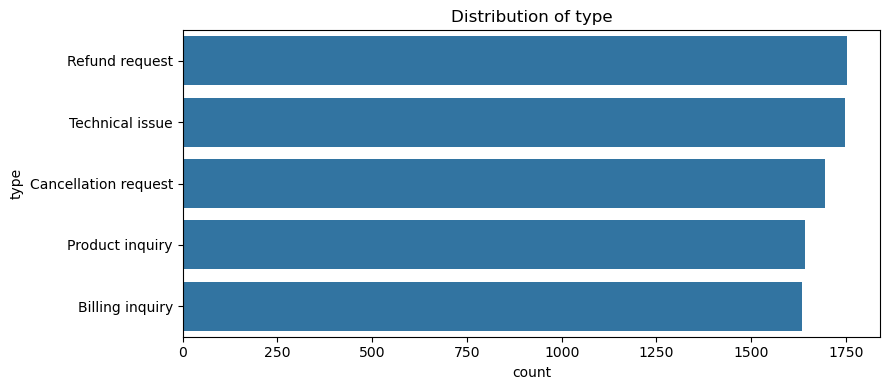


Value counts for type:
type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


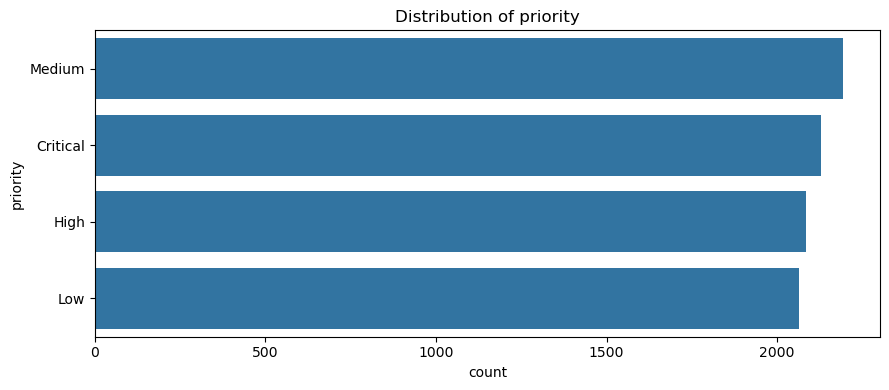


Value counts for priority:
priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64


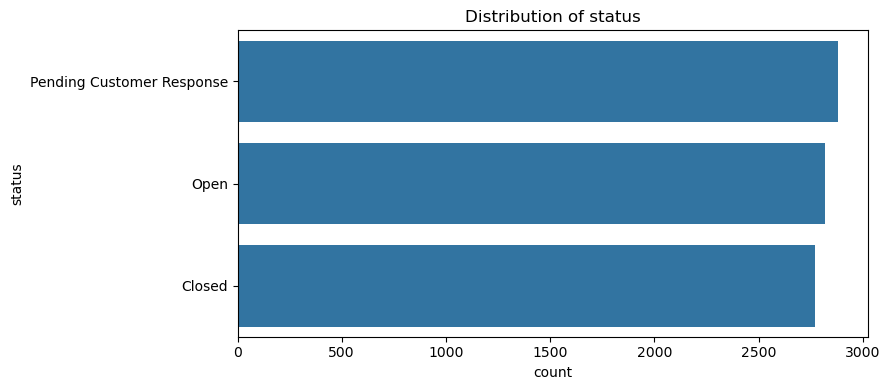


Value counts for status:
status
Pending Customer Response    2881
Open                         2819
Closed                       2769
Name: count, dtype: int64


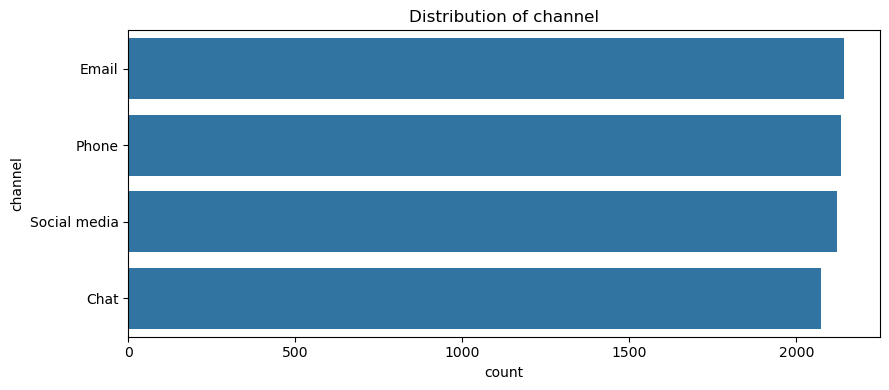


Value counts for channel:
channel
Email           2143
Phone           2132
Social media    2121
Chat            2073
Name: count, dtype: int64


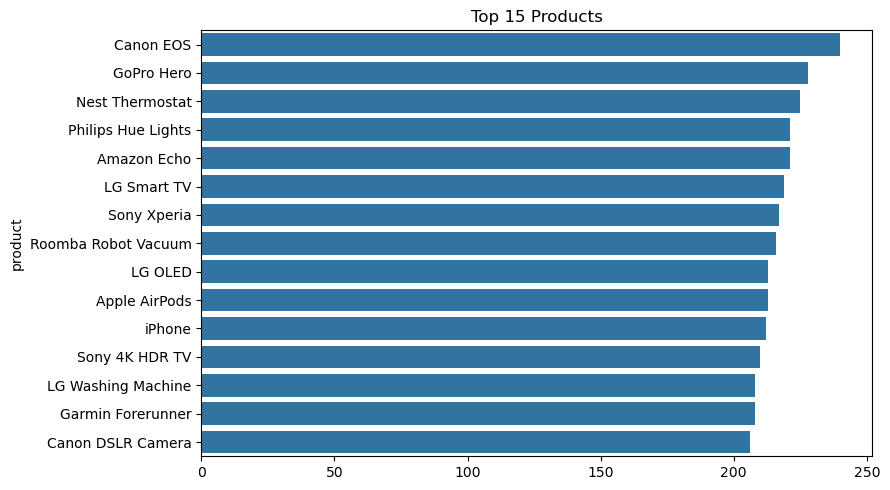


Top 15 products:
product
Canon EOS              240
GoPro Hero             228
Nest Thermostat        225
Philips Hue Lights     221
Amazon Echo            221
LG Smart TV            219
Sony Xperia            217
Roomba Robot Vacuum    216
LG OLED                213
Apple AirPods          213
iPhone                 212
Sony 4K HDR TV         210
LG Washing Machine     208
Garmin Forerunner      208
Canon DSLR Camera      206
Name: count, dtype: int64

Subject vs Type crosstab:
type                      Billing inquiry  ...  Technical issue
subject                                    ...                 
Account access                        103  ...               99
Battery life                          106  ...              112
Cancellation request                   82  ...              108
Data loss                              89  ...               99
Delivery problem                      115  ...              116
Display issue                          91  ...              105
Hard

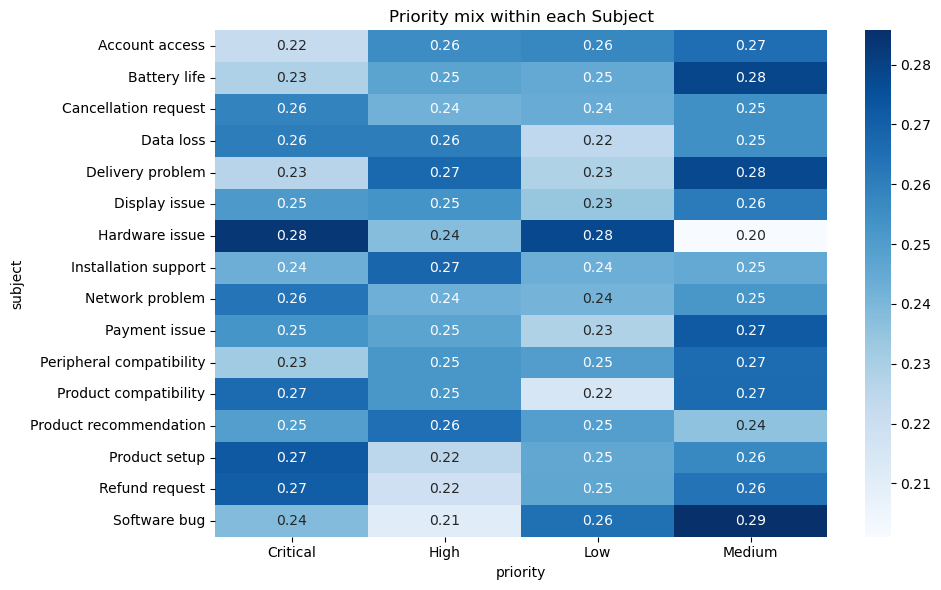


Subject vs Channel row-normalized:
channel                    Chat  Email  Phone  Social media
subject                                                    
Account access            0.246  0.265  0.238         0.251
Battery life              0.229  0.240  0.269         0.262
Cancellation request      0.234  0.238  0.261         0.267
Data loss                 0.224  0.277  0.240         0.259
Delivery problem          0.278  0.262  0.230         0.230
Display issue             0.259  0.255  0.262         0.224
Hardware issue            0.247  0.283  0.256         0.214
Installation support      0.209  0.249  0.262         0.279
Network problem           0.249  0.241  0.260         0.250
Payment issue             0.241  0.260  0.240         0.259
Peripheral compatibility  0.250  0.228  0.262         0.260
Product compatibility     0.259  0.250  0.252         0.238
Product recommendation    0.259  0.226  0.263         0.251
Product setup             0.234  0.280  0.214         0.272
Refu

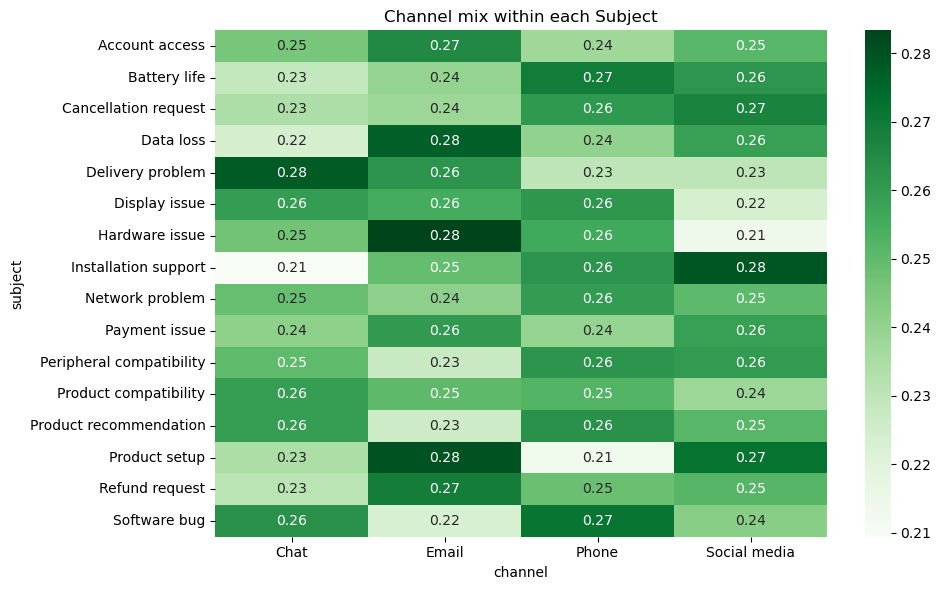


Top 20 product-subject pairs:
                       product                subject  count
270                 GoPro Hero         Refund request     28
395                MacBook Pro  Product compatibility     24
600             Sony 4K HDR TV        Network problem     23
239          Garmin Forerunner           Software bug     23
441  Microsoft Xbox Controller          Payment issue     22
20                 Amazon Echo       Delivery problem     22
557        Roomba Robot Vacuum          Product setup     22
145                  Canon EOS           Battery life     22
241        GoPro Action Camera           Battery life     22
425          Microsoft Surface          Payment issue     21
325                    LG OLED          Display issue     21
63               Apple AirPods           Software bug     21
568             Samsung Galaxy        Network problem     20
150                  Canon EOS         Hardware issue     20
382            Lenovo ThinkPad         Refund request 

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# 1. Basic distributions
# ----------------------------
cols_to_plot = ["subject", "type", "priority", "status", "channel"]

for col in cols_to_plot:
    plt.figure(figsize=(9, 4))
    order = eda_df[col].value_counts().index
    sns.countplot(data=eda_df, y=col, order=order)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()
    
    print(f"\nValue counts for {col}:")
    print(eda_df[col].value_counts())

# ----------------------------
# 2. Top products
# ----------------------------
top_products = eda_df["product"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 15 Products")
plt.tight_layout()
plt.show()

print("\nTop 15 products:")
print(top_products)

# ----------------------------
# 3. Subject vs Type
# ----------------------------
subject_type = pd.crosstab(eda_df["subject"], eda_df["type"])
print("\nSubject vs Type crosstab:")
print(subject_type)

# optional normalized version by subject row
subject_type_norm = pd.crosstab(eda_df["subject"], eda_df["type"], normalize="index")
print("\nSubject vs Type row-normalized:")
print(subject_type_norm.round(3))

# ----------------------------
# 4. Subject vs Priority
# ----------------------------
subject_priority = pd.crosstab(eda_df["subject"], eda_df["priority"])
print("\nSubject vs Priority crosstab:")
print(subject_priority)

subject_priority_norm = pd.crosstab(eda_df["subject"], eda_df["priority"], normalize="index")
print("\nSubject vs Priority row-normalized:")
print(subject_priority_norm.round(3))

# heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(subject_priority_norm, annot=True, fmt=".2f", cmap="Blues")
plt.title("Priority mix within each Subject")
plt.tight_layout()
plt.show()

# ----------------------------
# 5. Subject vs Channel
# ----------------------------
subject_channel_norm = pd.crosstab(eda_df["subject"], eda_df["channel"], normalize="index")
print("\nSubject vs Channel row-normalized:")
print(subject_channel_norm.round(3))

plt.figure(figsize=(10, 6))
sns.heatmap(subject_channel_norm, annot=True, fmt=".2f", cmap="Greens")
plt.title("Channel mix within each Subject")
plt.tight_layout()
plt.show()

# ----------------------------
# 6. Top Product-Subject pairs
# ----------------------------
product_subject_pairs = (
    eda_df.groupby(["product", "subject"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nTop 20 product-subject pairs:")
print(product_subject_pairs.head(20))

The metadata distributions are strikingly uniform across subjects, types, priorities, statuses, channels, and products, suggesting that the dataset is highly curated or synthetic rather than naturally imbalanced. Among the available labels, subject is clearly the most useful reference taxonomy because it is relatively fine-grained, whereas type shows only weak association with subject. Priority and channel vary only modestly across subjects, so they are more suitable for downstream interpretation than for defining the issue structure itself. Product incidence is also diffuse, which reduces the risk that issue discovery will be dominated by a small number of items.

Step 9: Subject-level lexical audit

The goal is to check whether the text actually contains distinctive vocabulary for each subject.

In [39]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# keep only non-empty issue-focused text
lex_df = eda_df[eda_df["text_issue_ready"].str.strip() != ""].copy()

print("Rows kept for lexical audit:", len(lex_df))
print("Rows removed because text_issue_ready was empty:", len(eda_df) - len(lex_df))

# TF-IDF on issue-focused text
vectorizer = TfidfVectorizer(min_df=5)
X = vectorizer.fit_transform(lex_df["text_issue_ready"])
terms = np.array(vectorizer.get_feature_names_out())

subjects = sorted(lex_df["subject"].unique())

subject_keyword_rows = []

for subj in subjects:
    mask = (lex_df["subject"].values == subj)
    mean_scores = np.asarray(X[mask].mean(axis=0)).ravel()
    top_idx = mean_scores.argsort()[::-1][:10]
    
    top_terms = terms[top_idx]
    top_scores = mean_scores[top_idx]
    
    for rank, (term, score) in enumerate(zip(top_terms, top_scores), start=1):
        subject_keyword_rows.append({
            "subject": subj,
            "rank": rank,
            "term": term,
            "score": score
        })

subject_keywords_df = pd.DataFrame(subject_keyword_rows)

# print top 10 keywords per subject
for subj in subjects:
    print("\n" + "="*90)
    print("SUBJECT:", subj)
    display_df = subject_keywords_df[subject_keywords_df["subject"] == subj][["rank", "term", "score"]]
    print(display_df.to_string(index=False))

# compact table: top 5 keywords per subject
summary_rows = []
for subj in subjects:
    top_terms = subject_keywords_df[subject_keywords_df["subject"] == subj].sort_values("rank")["term"].head(5).tolist()
    summary_rows.append({
        "subject": subj,
        "top_5_terms": ", ".join(top_terms)
    })

subject_keyword_summary = pd.DataFrame(summary_rows)
print("\n\nTop 5 terms per subject:")
print(subject_keyword_summary.to_string(index=False))

Rows kept for lexical audit: 8456
Rows removed because text_issue_ready was empty: 13

SUBJECT: Account access
 rank      term    score
    1      data 0.034282
    2   account 0.034105
    3  software 0.030868
    4     times 0.027624
    5    update 0.025325
    6    device 0.025152
    7    unable 0.024477
    8 available 0.023373
    9   updates 0.021697
   10      like 0.021423

SUBJECT: Battery life
 rank     term    score
    1     data 0.034805
    2    error 0.029875
    3  message 0.029784
    4 multiple 0.025124
    5 software 0.024634
    6 customer 0.024196
    7   update 0.024087
    8   unable 0.023693
    9    times 0.023560
   10   device 0.022889

SUBJECT: Cancellation request
 rank      term    score
    1      data 0.035637
    2  software 0.033585
    3   account 0.030804
    4     times 0.027611
    5    device 0.026495
    6       app 0.024646
    7 available 0.024343
    8    unable 0.023566
    9    update 0.022500
   10   updates 0.021705

SUBJECT: Data loss
 

The dataset is highly curated and partly templated, with structurally missing workflow fields, repaired product placeholders, narrow text-length distributions, and unusually balanced metadata categories. Basic frequency analysis was dominated by boilerplate, while more aggressive issue-focused preprocessing improved keyword quality but also removed useful context. Metadata analysis showed that subject is the most useful reference taxonomy, whereas type, priority, and channel are only weakly differentiated. Finally, subject-level lexical audit showed substantial vocabulary overlap across issue categories, implying that clustering quality should be judged not only by alignment with subject, but also by coherence and interpretability.

Use these columns in the next phase:

- text_issue_ready for keyword extraction and cluster naming
- text_no_product as the main text for TF-IDF clustering
- text_no_product or text_clean_basic for embedding-based clustering
- subject as a weak external reference label
- priority, channel, product for post-hoc interpretation of clusters

I would not use type as the main reference label.

after EDA

Now we start the actual pipeline required by Task 4: initial clustering with TF-IDF, checking stability across different k, and comparing against the weak reference label subject. The coursework explicitly asks for k-means or HAC on TF-IDF or embeddings and to examine coherence, interpretability, and stability across k

Step 10: Baseline TF-IDF + k-means stability sweep

Rows for clustering: 8469
TF-IDF matrix shape: (8469, 3016)

K sweep results:
    k  silhouette  ...  min_cluster_size  max_cluster_size
0   6    0.062001  ...               499              3553
1   8    0.082088  ...               470              4079
2  10    0.100994  ...               445              2484
3  12    0.119563  ...               445              1489
4  14    0.130061  ...               231              1006
5  16    0.145381  ...               231              1221
6  18    0.157680  ...               178               987
7  20    0.166593  ...               184               935

[8 rows x 6 columns]


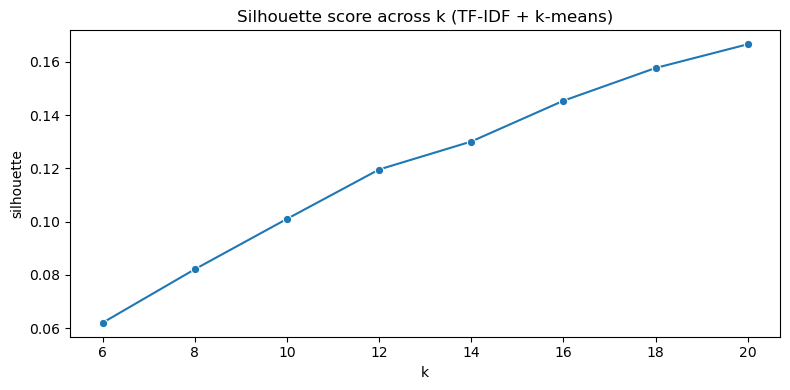

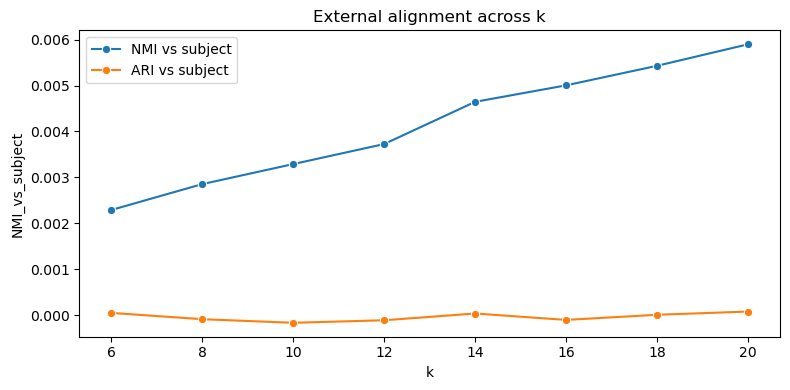


Cluster sizes for k=16:
cluster_k16
0      728
1      472
2      445
3      485
4     1221
5      443
6      485
7      470
8      502
9      490
10     250
11     460
12     499
13     799
14     489
15     231
Name: count, dtype: int64

Top terms per cluster for k=16:
 cluster                                                                                                                                                          top_terms
       0                        ve tried, tried, persists, issue persists, different, ve, different settings, settings configurations, configurations issue, configurations
       1                                      error message, message, error, says error, message does, popping screen, noticed peculiar, message popping, popping, peculiar
       2                                                    like ensure, security like, ensure data, concerned security, concerned, data safe, safe, security, ensure, like
       3                          need a

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# ----------------------------
# 1. Prepare modelling dataframe
# ----------------------------
cluster_df = eda_df[eda_df["text_no_product"].astype(str).str.strip() != ""].copy()
cluster_df = cluster_df.reset_index(drop=True)

print("Rows for clustering:", len(cluster_df))

# ----------------------------
# 2. TF-IDF representation
# Use text_no_product, not text_issue_ready, to preserve more context
# ----------------------------
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 2)
)

X_tfidf = tfidf_vectorizer.fit_transform(cluster_df["text_no_product"])

print("TF-IDF matrix shape:", X_tfidf.shape)

# ----------------------------
# 3. Sweep across k values
# subject is only a weak reference label
# ----------------------------
k_values = [6, 8, 10, 12, 14, 16, 18, 20]
results = []

subject_codes = cluster_df["subject"].astype("category").cat.codes

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_tfidf)
    
    sil = silhouette_score(X_tfidf, labels)
    ari = adjusted_rand_score(subject_codes, labels)
    nmi = normalized_mutual_info_score(subject_codes, labels)
    
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    min_cluster = cluster_sizes.min()
    max_cluster = cluster_sizes.max()
    
    results.append({
        "k": k,
        "silhouette": sil,
        "ARI_vs_subject": ari,
        "NMI_vs_subject": nmi,
        "min_cluster_size": min_cluster,
        "max_cluster_size": max_cluster
    })

results_df = pd.DataFrame(results)
print("\nK sweep results:")
print(results_df)

# ----------------------------
# 4. Plot metrics
# ----------------------------
plt.figure(figsize=(8, 4))
sns.lineplot(data=results_df, x="k", y="silhouette", marker="o")
plt.title("Silhouette score across k (TF-IDF + k-means)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(data=results_df, x="k", y="NMI_vs_subject", marker="o", label="NMI vs subject")
sns.lineplot(data=results_df, x="k", y="ARI_vs_subject", marker="o", label="ARI vs subject")
plt.title("External alignment across k")
plt.tight_layout()
plt.show()

# ----------------------------
# 5. Choose one candidate k for inspection
# Start with k=16 because subject has 16 categories
# ----------------------------
k_inspect = 16
km_16 = KMeans(n_clusters=k_inspect, random_state=42, n_init=20)
cluster_df["cluster_k16"] = km_16.fit_predict(X_tfidf)

print("\nCluster sizes for k=16:")
print(cluster_df["cluster_k16"].value_counts().sort_index())

# ----------------------------
# 6. Top TF-IDF terms per cluster
# ----------------------------
terms = np.array(tfidf_vectorizer.get_feature_names_out())
centers = km_16.cluster_centers_

cluster_terms = []
for c in range(k_inspect):
    top_idx = centers[c].argsort()[::-1][:10]
    top_terms = terms[top_idx]
    cluster_terms.append({
        "cluster": c,
        "top_terms": ", ".join(top_terms)
    })

cluster_terms_df = pd.DataFrame(cluster_terms)
print("\nTop terms per cluster for k=16:")
print(cluster_terms_df.to_string(index=False))

# ----------------------------
# 7. Weak external comparison: dominant subjects within each cluster
# ----------------------------
cluster_subject_table = pd.crosstab(cluster_df["cluster_k16"], cluster_df["subject"])

dominant_subjects = []
for c in cluster_subject_table.index:
    row = cluster_subject_table.loc[c].sort_values(ascending=False)
    dominant_subjects.append({
        "cluster": c,
        "top_subject_1": row.index[0],
        "top_subject_1_count": row.iloc[0],
        "top_subject_2": row.index[1],
        "top_subject_2_count": row.iloc[1],
    })

dominant_subjects_df = pd.DataFrame(dominant_subjects)
print("\nDominant subjects within each cluster (k=16):")
print(dominant_subjects_df.to_string(index=False))

The TF-IDF + k-means baseline produced increasingly separated clusters as k increased, but this did not translate into meaningful alignment with the subject labels. External alignment metrics remained near zero, and cluster inspection showed that the method primarily grouped tickets by repeated phrasal patterns and troubleshooting narratives rather than by high-level issue category. This suggests that sparse lexical features are sensitive to templated language in the dataset, making TF-IDF clustering better suited to discovering recurring complaint formulations than to recovering a semantic issue taxonomy.